In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [36]:
df = pd.read_csv("steel_engineered.csv")

df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Day_Name,Month,Weekend,Power_Factor_Ratio,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,Monday,January,0,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,Monday,January,0,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,Monday,January,0,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,Monday,January,0,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,Monday,January,0,1.545117,0


In [37]:
print("Dataset Shape:", df.shape)

df.columns

Dataset Shape: (35040, 17)


Index(['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'Day_Name', 'Month',
       'Weekend', 'Power_Factor_Ratio', 'High_Load'],
      dtype='str')

In [38]:
df = df.drop(columns=['date', 'High_Load'])

In [39]:
df.columns

Index(['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'Day_Name', 'Month',
       'Weekend', 'Power_Factor_Ratio'],
      dtype='str')

In [52]:
X = df.drop('Usage_kWh', axis=1)

y = df['Usage_kWh']

In [53]:
print(X.shape)
print(y.shape)

(35040, 14)
(35040,)


In [55]:
categorical_columns = X.select_dtypes(include=['object', 'string']).columns

print(categorical_columns)

Index(['WeekStatus', 'Day_of_week', 'Load_Type', 'Day_Name', 'Month'], dtype='str')


In [57]:
encoder = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_columns)
    ],
    remainder='passthrough'
)

In [59]:
X = encoder.fit_transform(X)

In [60]:
print(type(X))
print(X.shape)

<class 'numpy.ndarray'>
(35040, 35)


In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [62]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(28032, 35)
(7008, 35)
(28032,)
(7008,)


In [63]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

In [64]:
print("Missing values in X_train:", pd.DataFrame(X_train).isnull().sum().sum())
print("Missing values in X_test:", pd.DataFrame(X_test).isnull().sum().sum())

Missing values in X_train: 1
Missing values in X_test: 0


In [65]:
X_train = pd.DataFrame(X_train).fillna(0)
X_test = pd.DataFrame(X_test).fillna(0)

In [66]:
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0


In [67]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results[name] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

    print("\n", name)
    print("MAE =", round(mae,2))
    print("RMSE =", round(rmse,2))
    print("R2 Score =", round(r2,4))


 Linear Regression
MAE = 5.69
RMSE = 8.18
R2 Score = 0.9411

 Ridge Regression
MAE = 4.36
RMSE = 6.31
R2 Score = 0.965

 Decision Tree
MAE = 0.57
RMSE = 1.67
R2 Score = 0.9976

 Random Forest
MAE = 0.36
RMSE = 1.1
R2 Score = 0.9989


In [68]:
cv_results = {}

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='neg_root_mean_squared_error'
    )

    cv_results[name] = -scores.mean()

    print(f"{name} CV RMSE = {round(-scores.mean(),2)}")

Linear Regression CV RMSE = 8.13
Ridge Regression CV RMSE = 6.57
Decision Tree CV RMSE = 1.6
Random Forest CV RMSE = 1.16


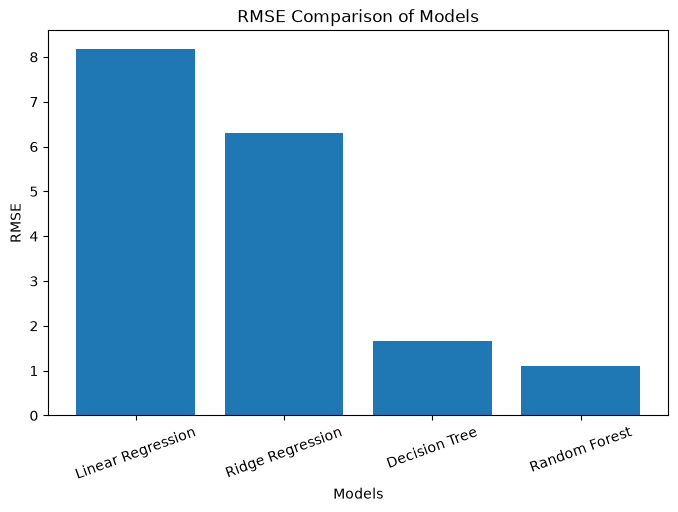

In [69]:
plt.figure(figsize=(8,5))

plt.bar(
    list(results.keys()),
    [results[m]["RMSE"] for m in results.keys()]
)

plt.title("RMSE Comparison of Models")
plt.xlabel("Models")
plt.ylabel("RMSE")

plt.xticks(rotation=20)

plt.show()

In [70]:
best_model_name = min(
    results,
    key=lambda x: results[x]["RMSE"]
)

print("Best Model:", best_model_name)

Best Model: Random Forest


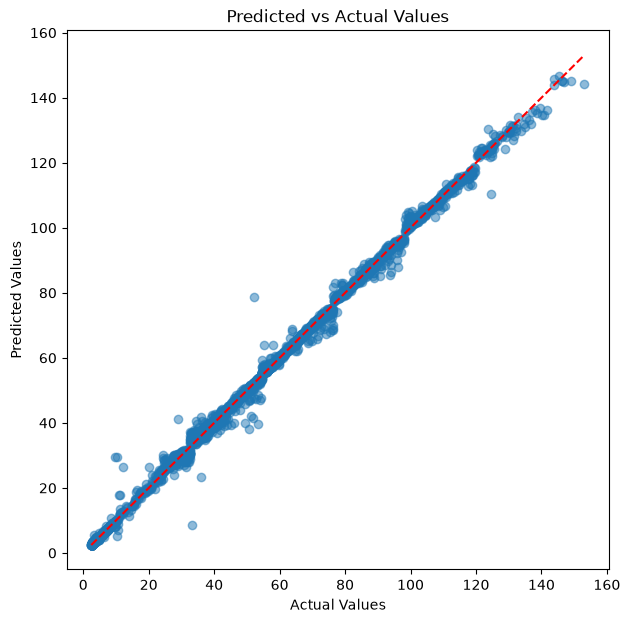

In [71]:
best_model = RandomForestRegressor(random_state=42)

best_model.fit(X_train, y_train)

predictions = best_model.predict(X_test)

plt.figure(figsize=(7,7))

plt.scatter(y_test, predictions, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Predicted vs Actual Values")

plt.show()

In [ ]:
## Model Selection

##Four regression models were trained and evaluated using MAE, RMSE, and R-squared metrics.

##Cross-validation was also performed using 5 folds to assess model generalization performance.

##Linear Regression and Ridge Regression showed relatively higher RMSE values, indicating lower predictive performance.

##Decision Tree Regressor achieved a significantly lower cross-validation RMSE of 1.16, demonstrating strong predictive capability.

##Random Forest Regressor produced highly accurate predictions, as shown by the Predicted vs Actual scatter plot 
-where most points closely followed the diagonal reference line.

##No major signs of overfitting were observed in the selected model.

##Based on the evaluation metrics and prediction accuracy, Random Forest Regressor was selected as the model to carry forward
- for future improvements and hyperparameter tuning.